# 13. Dimensionality Reduction, PCA, Embeddings, and Visualization

High-dimensional data creates a recurring decision-science problem. We often log dozens or hundreds of variables about customers, products, transactions, systems, or operations, but we still need compact representations that support interpretation, monitoring, segmentation, and modeling. Dimensionality reduction is one answer to that problem.

Principal component analysis (PCA) is the classical starting point: it takes correlated variables and rewrites them as orthogonal components ordered by how much variance they explain (Abdi & Williams, 2010; Jolliffe & Cadima, 2016). Nonlinear embedding methods such as t-SNE are often used when analysts want low-dimensional visualizations of complex structure that may not be well captured by a straight linear projection (Kang et al., 2020). More broadly, manifold-learning approaches are motivated by the idea that high-dimensional observations may lie near lower-dimensional structure, with an emphasis on preserving local or global geometry (Ozturk & Yilmaz, 2021).

This notebook is about using these tools carefully. We will separate three goals that are often conflated:

1. **compression**: replace many variables with a smaller set of summary dimensions,
2. **visualization**: project data into two dimensions so that humans can inspect structure,
3. **representation for downstream tasks**: build lower-dimensional features that may still preserve predictive signal.

Those goals overlap, but they are not the same. PCA can be useful for all three. t-SNE is often useful for the second and sometimes for exploratory insight, but deployment still needs a separate representation check.

## Learning Objectives

By the end of this lecture, you should be able to:

1. explain the optimization logic behind PCA,
2. interpret explained variance, scores, and loadings more carefully,
3. distinguish between linear compression and nonlinear visualization embeddings,
4. diagnose when a two-dimensional plot is informative versus potentially misleading,
5. use PCA on operational tabular data to summarize structure and support downstream modeling decisions,
6. decide when dimensionality reduction helps interpretation, computation, or predictive stability.


## 1. Core Mathematical Ideas

Suppose our data matrix is $X \in \mathbb{R}^{n \times p}$, where rows are observations and columns are variables. After centering each column, PCA looks for a direction $w_1$ that maximizes projected variance:

$$
\max_{\lVert w_1 \rVert_2 = 1} \operatorname{Var}(X w_1).
$$

If $S$ is the sample covariance matrix, this becomes

$$
\max_{\lVert w_1 \rVert_2 = 1} w_1^\top S w_1.
$$

The solution is the leading eigenvector of $S$, and the corresponding eigenvalue $\lambda_1$ is the variance explained by the first principal component. The second component solves the same problem subject to orthogonality with the first, and so on.

If we collect the first $k$ loading vectors into a matrix $W_k = [w_1, \dots, w_k]$, then the principal-component scores are

$$
Z_k = X W_k,
$$

and a rank-$k$ reconstruction is

$$
\widehat{X}_k = Z_k W_k^\top.
$$

This gives us a very useful decomposition of the dimensionality-reduction problem:

- **scores** tell us where observations live in the reduced space,
- **loadings** tell us how original variables contribute to each component,
- **explained variance** tells us how much of the original variation survives compression.

Jolliffe and Cadima (2016) emphasize that a standard quality measure for PCA is the proportion of total variance explained by a component or a set of components, and that graphical representations often focus on the first two or three components even when those components do not capture all variability. That is a powerful habit, but also a dangerous one: low-dimensional plots are summaries, not the full data-generating reality.

### PCA versus embedding methods

PCA is linear. A two-dimensional PCA plot is obtained by projecting onto two orthogonal directions in the original variable space. By contrast, nonlinear dimensionality-reduction methods such as t-SNE try to create low-dimensional embeddings that preserve neighborhood structure in a more flexible way. Kang, Garcia Garcia, and Lijffijt (2020) describe these methods as tools for producing low-dimensional embeddings that support visualization and exploration of high-dimensional data.

That difference matters operationally:

- PCA gives an explicit transformation that can be reused for new data.
- t-SNE primarily gives a visualization-oriented embedding of the sample at hand.
- PCA loadings are interpretable as combinations of original variables.
- t-SNE axes usually do **not** admit direct substantive interpretation.


In [1]:
# Section focus: PCA versus embedding methods.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.special import expit

from sklearn.datasets import make_swiss_roll
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE, trustworthiness
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
pd.set_option('display.max_colwidth', 200)
pd.options.display.float_format = '{:,.3f}'.format

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

rng = np.random.default_rng(2026)


## 2. A Geometry Benchmark: Linear Projection versus Nonlinear Embedding

We begin with a benchmark where the difference between a linear summary and a nonlinear embedding is easy to see. The **swiss roll** dataset lives in three observed dimensions, but the data actually lie on a curved two-dimensional manifold folded through space.

That makes it a good teaching example:

- A two-dimensional PCA projection can still summarize broad variation.
- But PCA cannot "unroll" the manifold because PCA only rotates and projects linearly.
- A nonlinear embedding such as t-SNE can often preserve local neighborhoods much more effectively for visualization.

To keep the comparison concrete, we will compute **trustworthiness**, a neighborhood-preservation diagnostic for low-dimensional embeddings. Higher values indicate that local neighborhoods in the embedding better agree with the neighborhoods in the original space.


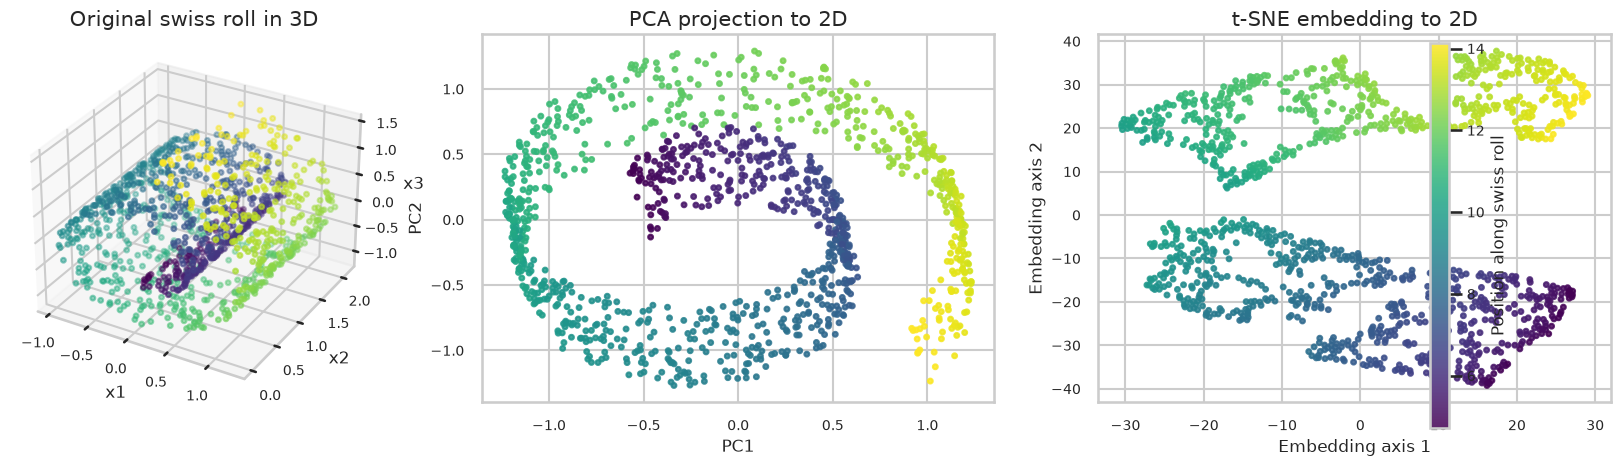

,embedding,trustworthiness_at_12_neighbors
0,PCA (2D),0.967
1,t-SNE (2D),0.999


In [2]:
# Section focus: 2. A Geometry Benchmark: Linear Projection versus Nonlinear Embedding.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


X_roll, roll_color = make_swiss_roll(n_samples=1200, noise=0.12, random_state=12)
X_roll = X_roll / np.array([10.0, 10.0, 10.0])

pca_roll = PCA(n_components=2, random_state=12)
roll_pca_2d = pca_roll.fit_transform(X_roll)

roll_tsne_2d = TSNE(
    n_components=2,
    perplexity=35,
    init='pca',
    learning_rate='auto',
    max_iter=1000,
    random_state=12,
).fit_transform(X_roll)

embedding_quality = pd.DataFrame([
    {
        'embedding': 'PCA (2D)',
        'trustworthiness_at_12_neighbors': trustworthiness(X_roll, roll_pca_2d, n_neighbors=12),
    },
    {
        'embedding': 't-SNE (2D)',
        'trustworthiness_at_12_neighbors': trustworthiness(X_roll, roll_tsne_2d, n_neighbors=12),
    },
]).round(3)

fig = plt.figure(figsize=(18, 5))

ax = fig.add_subplot(1, 3, 1, projection='3d')
ax.scatter(X_roll[:, 0], X_roll[:, 1], X_roll[:, 2], c=roll_color, cmap='viridis', s=12, alpha=0.85)
ax.set_title('Original swiss roll in 3D')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('x3')

ax = fig.add_subplot(1, 3, 2)
scatter = ax.scatter(roll_pca_2d[:, 0], roll_pca_2d[:, 1], c=roll_color, cmap='viridis', s=12, alpha=0.85)
ax.set_title('PCA projection to 2D')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')

ax = fig.add_subplot(1, 3, 3)
ax.scatter(roll_tsne_2d[:, 0], roll_tsne_2d[:, 1], c=roll_color, cmap='viridis', s=12, alpha=0.85)
ax.set_title('t-SNE embedding to 2D')
ax.set_xlabel('Embedding axis 1')
ax.set_ylabel('Embedding axis 2')

cbar = fig.colorbar(scatter, ax=fig.axes, fraction=0.02, pad=0.02)
cbar.set_label('Position along swiss roll')
plt.tight_layout()
plt.show()

embedding_quality


On this benchmark, the contrast should be visible even before we look at the table. The PCA projection preserves a broad global orientation, but nearby points on the curved manifold can be folded across each other after projection. The t-SNE embedding usually creates a much cleaner low-dimensional neighborhood picture.

The trustworthiness values quantify that visual impression. In this example, t-SNE preserves local neighborhoods substantially better than the two-dimensional PCA projection. That does **not** mean t-SNE is always the better method. It means the benchmark geometry is nonlinear, so a nonlinear visualization tool has an advantage.

Two cautionary lessons follow immediately:

1. **A good 2D plot is not the same thing as a good deployable representation.**
2. **Axes in t-SNE are not interpretable in the same way as PCA axes.**

This distinction becomes crucial in real business data, where we may want dimensionality reduction for stable, reusable operational features as well as pictures.


## 3. Operational Example: High-Dimensional Marketplace Accounts

We now switch from controlled geometry to a synthetic but realistic operational dataset. Imagine we manage a marketplace support-and-reliability system and want to summarize accounts using many logged features. The data contain overlapping latent factors such as:

- **account scale**,
- **operational burden and friction**,
- **self-service maturity**,
- **growth and promotion intensity**.

These factors are not observed directly. Instead, we observe correlated operational variables that partly reflect them. This is exactly the kind of structure where PCA can be useful: several measured variables may be telling us overlapping stories about a smaller number of latent business dimensions.

### Feature dictionary

| Variable | Interpretation |
|---|---|
| `monthly_gmv_log`, `active_skus_log`, `avg_order_value_log` | Scale and economic footprint |
| `cross_border_share`, `payment_friction_rate`, `dispute_rate` | Friction and complexity in operations |
| `feature_adoption_score`, `api_integration_share`, `self_service_share`, `knowledge_base_usage` | Product maturity and self-service capability |
| `promo_dependence`, `seasonal_spike_index`, `order_volatility` | Growth pressure and demand instability |
| `support_touches_30d`, `response_delay_hours`, `analyst_override_rate`, `cost_per_ticket` | Support burden and manual operational load |
| `breach_next_month` | Binary downstream operational risk outcome used later for evaluation |

We will also carry a hidden segment label only for teaching diagnostics. In real unsupervised learning we usually do **not** get the luxury of a true segment label.


In [3]:
# Section focus: Feature dictionary.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


def simulate_platform_accounts(n=3200, random_state=2026):
    """Create a simulated platform accounts data set for the 13. Dimensionality Reduction, PCA, Embeddings, and Visualization case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    random_state : object
        Random seed or generator control used to make results reproducible.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    rng = np.random.default_rng(random_state)
    segment_names = np.array([
        'Enterprise scale accounts',
        'High-growth promotional accounts',
        'Long-tail self-service accounts',
        'Cross-border high-friction accounts',
    ])
    segment_probs = np.array([0.24, 0.26, 0.30, 0.20])
    seg = rng.choice(len(segment_names), size=n, p=segment_probs)

    latent_means = np.array([
        [1.5, 0.8, -0.3, 0.6],
        [0.8, 0.4, -0.6, 1.5],
        [-0.8, -0.7, 1.6, -0.5],
        [0.3, 1.6, -0.4, 0.4],
    ])
    latent = latent_means[seg] + rng.normal(scale=[0.45, 0.45, 0.45, 0.40], size=(n, 4))
    scale, burden, selfserve, growth = latent.T

    df = pd.DataFrame({
        'monthly_gmv_log': 9.2 + 0.75 * scale + 0.12 * growth + rng.normal(0, 0.22, n),
        'active_skus_log': 6.1 + 0.62 * scale + 0.15 * growth + rng.normal(0, 0.28, n),
        'avg_order_value_log': 4.0 + 0.48 * scale - 0.10 * growth + rng.normal(0, 0.20, n),
        'cross_border_share': expit(-0.1 + 1.10 * burden - 0.25 * selfserve + rng.normal(0, 0.45, n)),
        'feature_adoption_score': 56 + 8.0 * selfserve + 2.5 * scale + rng.normal(0, 5.0, n),
        'api_integration_share': expit(-0.3 + 1.00 * selfserve + 0.30 * scale + rng.normal(0, 0.42, n)),
        'order_volatility': 0.35 + 0.16 * growth + 0.12 * burden + rng.normal(0, 0.08, n),
        'promo_dependence': expit(0.1 + 1.10 * growth - 0.20 * scale + rng.normal(0, 0.40, n)),
        'seasonal_spike_index': 0.75 + 0.25 * growth + rng.normal(0, 0.10, n),
        'support_touches_30d': 5.5 + 1.8 * burden + 0.8 * scale - 0.5 * selfserve + rng.normal(0, 0.9, n),
        'response_delay_hours': 9.0 + 2.2 * burden - 0.8 * selfserve + rng.normal(0, 1.1, n),
        'payment_friction_rate': expit(-0.7 + 1.25 * burden + rng.normal(0, 0.45, n)),
        'dispute_rate': expit(-1.0 + 1.10 * burden + 0.30 * growth + rng.normal(0, 0.42, n)),
        'self_service_share': expit(-0.2 + 1.30 * selfserve - 0.35 * burden + rng.normal(0, 0.42, n)),
        'knowledge_base_usage': 12 + 5.5 * selfserve - 1.1 * burden + rng.normal(0, 2.0, n),
        'analyst_override_rate': expit(-0.4 + 0.90 * burden - 0.55 * selfserve + rng.normal(0, 0.40, n)),
        'cost_per_ticket': 18 + 3.4 * burden + 1.2 * scale - 1.1 * selfserve + rng.normal(0, 1.5, n),
    })

    risk_score = -3.1 + 1.0 * burden + 0.55 * growth - 0.75 * selfserve + 0.20 * scale
    df['breach_next_month'] = rng.binomial(1, expit(risk_score))
    df['hidden_segment'] = pd.Categorical(segment_names[seg], categories=segment_names)
    return df


df_accounts = simulate_platform_accounts()
feature_cols = [c for c in df_accounts.columns if c not in ['hidden_segment', 'breach_next_month']]

segment_snapshot = (
    df_accounts
    .groupby('hidden_segment')[['monthly_gmv_log', 'support_touches_30d', 'self_service_share', 'promo_dependence', 'breach_next_month']]
    .mean()
    .round(3)
)

segment_snapshot


,monthly_gmv_log,support_touches_30d,self_service_share,promo_dependence,breach_next_month
hidden_segment,,,,,
Enterprise scale accounts,10.413,8.336,0.308,0.607,0.227
High-growth promotional accounts,9.962,7.138,0.276,0.813,0.240
Long-tail self-service accounts,8.533,2.805,0.875,0.432,0.004
Cross-border high-friction accounts,9.487,8.826,0.242,0.607,0.325


The hidden segments are intentionally different in ways that overlap:

- enterprise accounts are large and operationally heavy,
- promotional accounts grow quickly and rely heavily on demand stimulation,
- self-service accounts are operationally efficient and low-risk,
- cross-border high-friction accounts experience the greatest burden and the highest future breach rate.

This overlap is exactly why we should expect correlated variables and a potentially lower-dimensional structure.


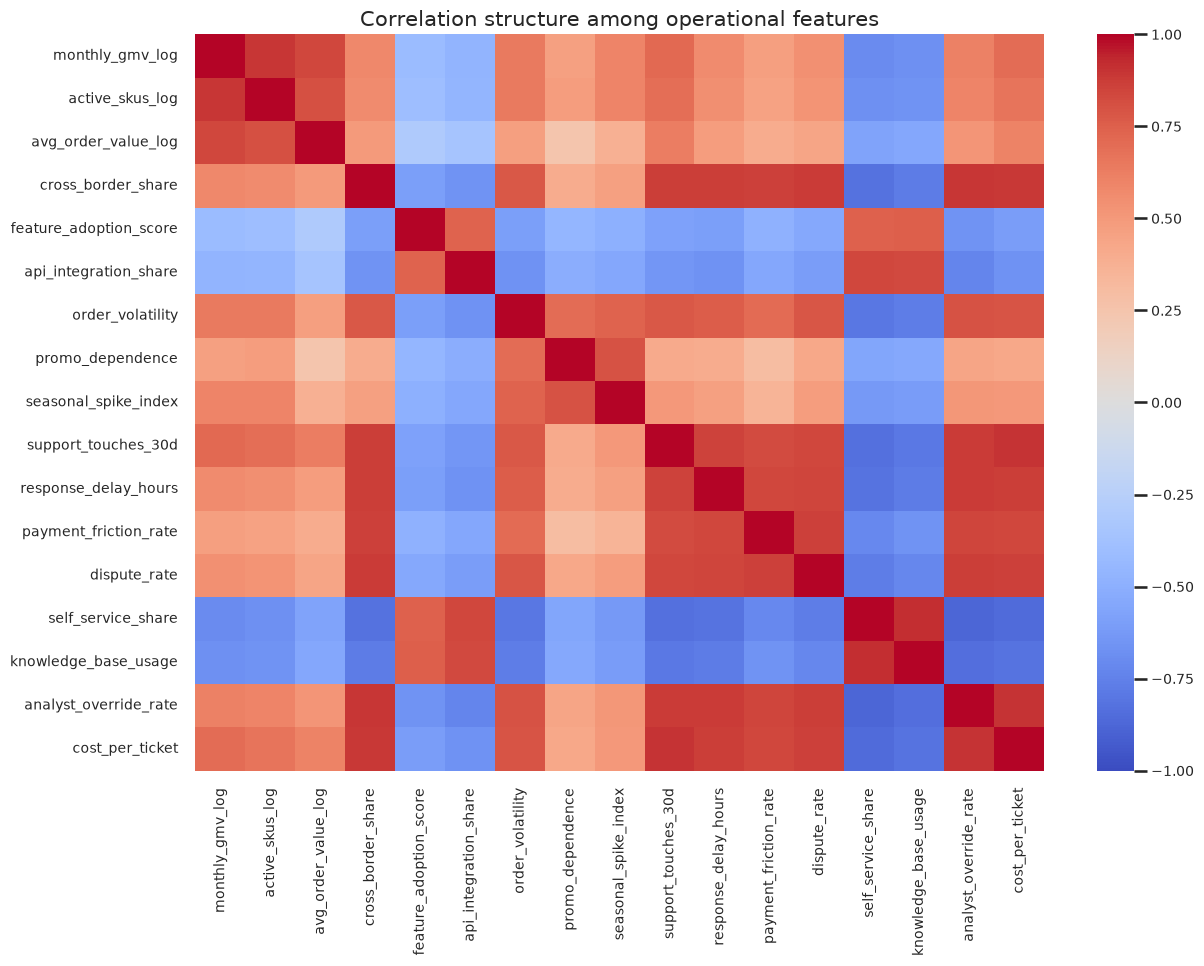

In [4]:

correlation_matrix = df_accounts[feature_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation structure among operational features')
plt.tight_layout()
plt.show()


The heatmap should show several blocks of related variables rather than a random cloud of weak relationships. For example:

- self-service variables should move together,
- support-burden variables should move together,
- scale variables should move together,
- promotion and volatility variables should form another related cluster.

That is the kind of redundancy PCA is designed to compress.


## 4. Fitting PCA to Standardized Operational Features

Because the variables live on very different numerical scales, we standardize them before fitting PCA. Otherwise, variables with large raw variance would dominate the components simply because of units.

After standardization, each feature contributes on a comparable scale, and the principal components summarize common directions of variation across the feature set.


In [5]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_accounts[feature_cols])

pca_full = PCA(random_state=22)
account_scores = pca_full.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    'component': [f'PC{i}' for i in range(1, len(feature_cols) + 1)],
    'explained_variance_ratio': pca_full.explained_variance_ratio_,
    'cumulative_explained_variance': np.cumsum(pca_full.explained_variance_ratio_),
})

explained_variance.head(10)


,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.684,0.684
1,PC2,0.092,0.776
2,PC3,0.080,0.856
3,PC4,0.044,0.900
4,PC5,0.016,0.916
5,PC6,0.011,0.927
6,PC7,0.009,0.936
7,PC8,0.009,0.944
8,PC9,0.008,0.952
9,PC10,0.007,0.960


The Fitting PCA to Standardized Operational Features result matters when it changes the next move. The evidence should make the next review question sharper.


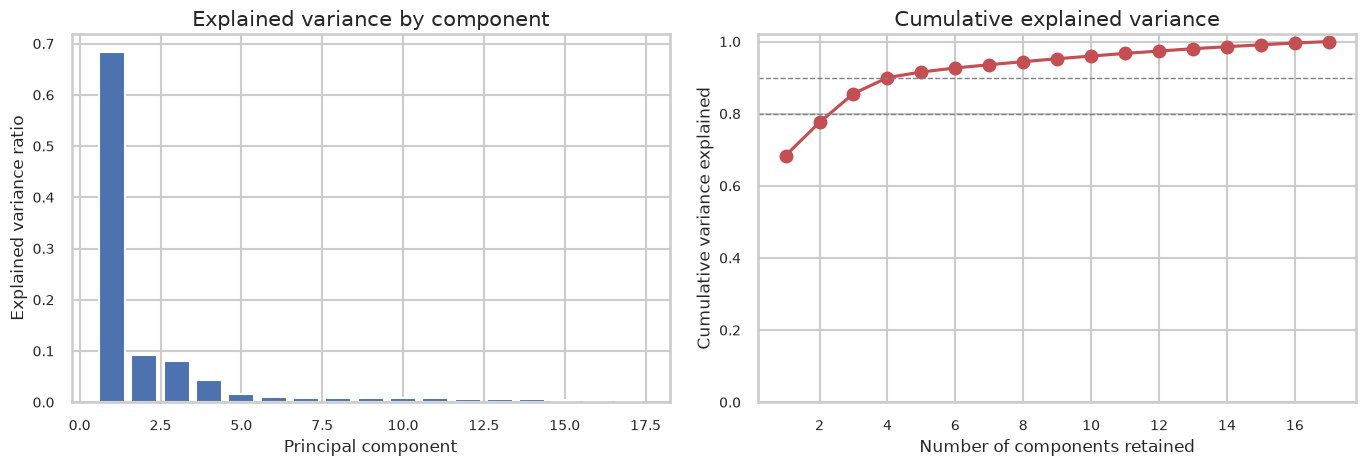

,components_retained,cumulative_explained_variance
0,2,0.776
1,4,0.900
2,6,0.927
3,8,0.944


In [6]:
# Section focus: 4. Fitting PCA to Standardized Operational Features.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, len(feature_cols) + 1), pca_full.explained_variance_ratio_, color='#4C72B0')
axes[0].set_title('Explained variance by component')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(range(1, len(feature_cols) + 1), np.cumsum(pca_full.explained_variance_ratio_), marker='o', color='#C44E52')
axes[1].axhline(0.80, linestyle='--', color='gray', linewidth=1)
axes[1].axhline(0.90, linestyle='--', color='gray', linewidth=1)
axes[1].set_title('Cumulative explained variance')
axes[1].set_xlabel('Number of components retained')
axes[1].set_ylabel('Cumulative variance explained')
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

variance_checkpoints = pd.DataFrame([
    {'components_retained': 2, 'cumulative_explained_variance': pca_full.explained_variance_ratio_[:2].sum()},
    {'components_retained': 4, 'cumulative_explained_variance': pca_full.explained_variance_ratio_[:4].sum()},
    {'components_retained': 6, 'cumulative_explained_variance': pca_full.explained_variance_ratio_[:6].sum()},
    {'components_retained': 8, 'cumulative_explained_variance': pca_full.explained_variance_ratio_[:8].sum()},
]).round(3)

variance_checkpoints


The variance profile tells us how concentrated the structure is.

If the first few components explain a large share of the variance, then the operational table is highly compressible. In this simulation, a modest number of components already captures most of the variation. That tells us the 17 observed variables are not describing 17 independent business dimensions. They are noisy measurements of a smaller number of underlying operational forces.

This is also where we should resist a common mistake: **high explained variance still requires interpretation checks**. We still have to inspect scores and loadings.


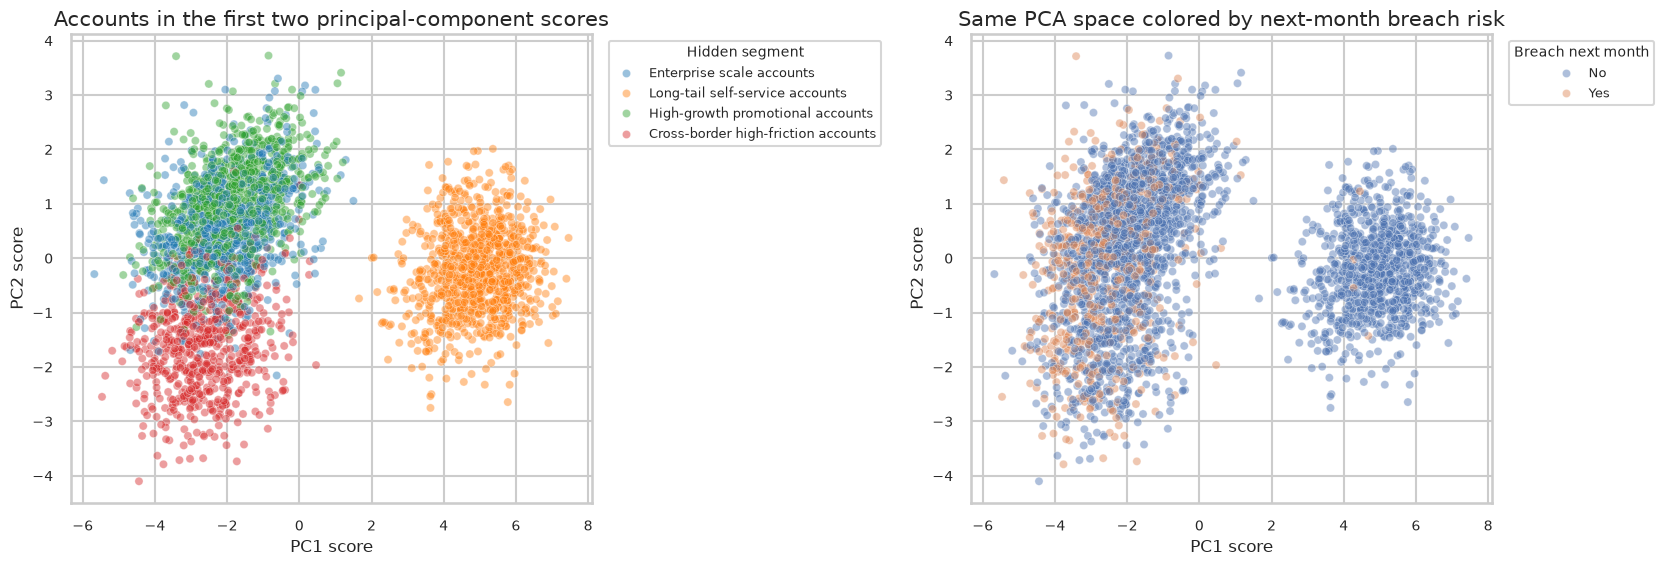

In [7]:
# Section focus: 4. Fitting PCA to Standardized Operational Features.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

score_frame = pd.DataFrame(account_scores[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
score_frame['hidden_segment'] = df_accounts['hidden_segment'].to_numpy()
score_frame['breach_next_month'] = df_accounts['breach_next_month'].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

sns.scatterplot(
    data=score_frame,
    x='PC1',
    y='PC2',
    hue='hidden_segment',
    palette='tab10',
    alpha=0.45,
    s=35,
    ax=axes[0],
)
axes[0].set_title('Accounts in the first two principal-component scores')
axes[0].set_xlabel('PC1 score')
axes[0].set_ylabel('PC2 score')
axes[0].legend(
    title='Hidden segment',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

sns.scatterplot(
    data=score_frame,
    x='PC1',
    y='PC2',
    hue='breach_next_month',
    palette={0: '#4C72B0', 1: '#DD8452'},
    alpha=0.45,
    s=35,
    ax=axes[1],
)
axes[1].set_title('Same PCA space colored by next-month breach risk')
axes[1].set_xlabel('PC1 score')
axes[1].set_ylabel('PC2 score')
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(
    handles=handles,
    labels=['No', 'Yes'],
    title='Breach next month',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=True,
    fontsize=9,
    title_fontsize=10,
)

plt.tight_layout()
plt.show()


A score plot like this can be genuinely useful, but only if we interpret it modestly.

- If groups separate strongly in the first two components, the operational table has a meaningful low-dimensional summary.
- If groups overlap heavily, the relevant variation may simply live beyond two dimensions.
- Coloring by the downstream outcome helps us ask whether the reduced representation aligns with decision-relevant differences rather than just pretty geometry.

Notice how this is a more defensible PCA use case than the swiss-roll example. Here, the data were generated from a small number of latent business drivers, so linear combinations are a more natural summary device.


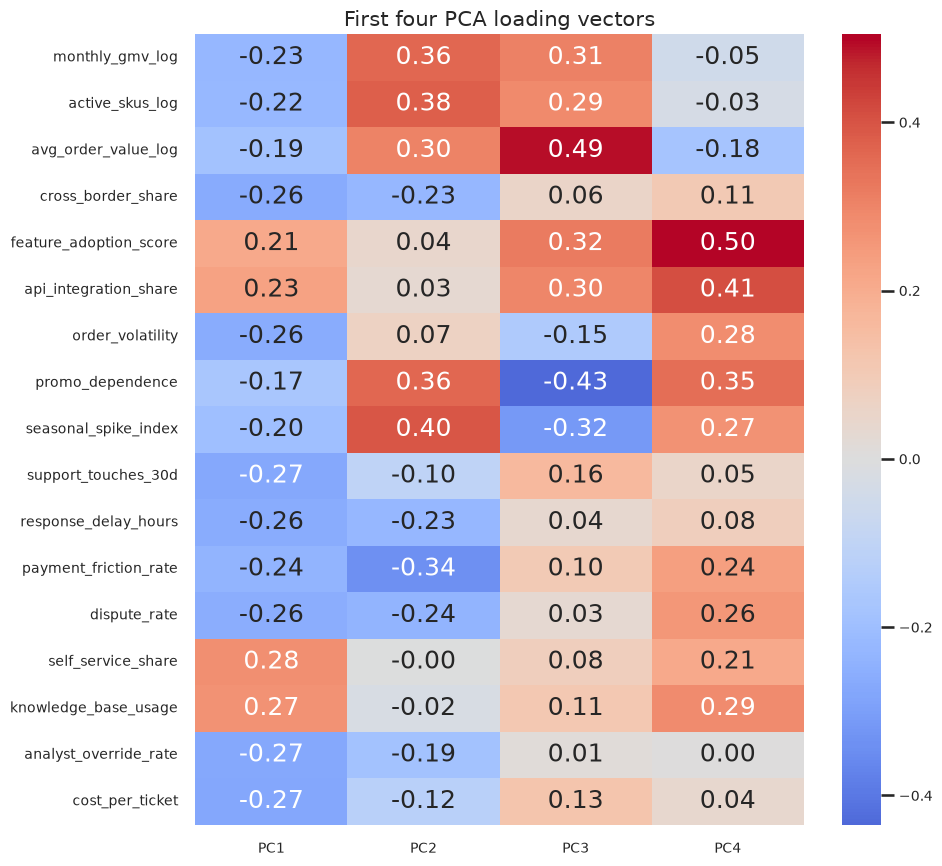

,component,strongest_positive_loadings,strongest_negative_loadings
0,PC1,"self_service_share (0.28), knowledge_base_usage (0.27), api_integration_share (0.23)","cost_per_ticket (-0.27), analyst_override_rate (-0.27), support_touches_30d (-0.27)"
1,PC2,"seasonal_spike_index (0.40), active_skus_log (0.38), monthly_gmv_log (0.36)","payment_friction_rate (-0.34), dispute_rate (-0.24), response_delay_hours (-0.23)"
2,PC3,"avg_order_value_log (0.49), feature_adoption_score (0.32), monthly_gmv_log (0.31)","promo_dependence (-0.43), seasonal_spike_index (-0.32), order_volatility (-0.15)"
3,PC4,"feature_adoption_score (0.50), api_integration_share (0.41), promo_dependence (0.35)","avg_order_value_log (-0.18), monthly_gmv_log (-0.05), active_skus_log (-0.03)"


In [8]:
# Section focus: 4. Fitting PCA to Standardized Operational Features.
# The code below keeps the calculation explicit so each intermediate step can be inspected.


loadings = pd.DataFrame(
    pca_full.components_[:4].T,
    index=feature_cols,
    columns=['PC1', 'PC2', 'PC3', 'PC4'],
)

plt.figure(figsize=(10, 9))
sns.heatmap(loadings, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.title('First four PCA loading vectors')
plt.tight_layout()
plt.show()

loading_summary_rows = []
for component in loadings.columns:
    s = loadings[component]
    positive = ', '.join([f"{name} ({value:.2f})" for name, value in s.sort_values(ascending=False).head(3).items()])
    negative = ', '.join([f"{name} ({value:.2f})" for name, value in s.sort_values().head(3).items()])
    loading_summary_rows.append({
        'component': component,
        'strongest_positive_loadings': positive,
        'strongest_negative_loadings': negative,
    })

loading_summary = pd.DataFrame(loading_summary_rows)
loading_summary


The loading patterns let us attach substantive meaning to the components.

A typical interpretation in this simulation is:

- **PC1** contrasts self-service maturity against manual support burden and friction.
- **PC2** captures a mix of scale and promotional intensity versus friction-heavy operational drag.
- **PC3** separates higher-order-value, more established accounts from more promotion-driven accounts.
- **PC4** refines differences in digital product adoption and integration intensity.

These are not "true" labels supplied by the algorithm. They are analyst interpretations of the loading structure. That is an important discipline point: PCA does not give us business meaning for free. It gives us directions of variation, and we must interpret them responsibly.


## 5. Compression Quality: How Much Information Do We Lose?

A convenient reconstruction diagnostic is the root-mean-squared reconstruction error after standardization:

$$
\operatorname{RMSE}_k = \sqrt{\frac{1}{np} \sum_{i=1}^n \sum_{j=1}^p \left(X_{ij}^{(\mathrm{std})} - \widehat{X}_{ij,k}^{(\mathrm{std})}\right)^2 }.
$$

As we retain more components, reconstruction error should fall. This is a direct way to connect variance-explained language to actual information loss in the standardized feature table.


In [9]:

reconstruction_rows = []
for k in [2, 4, 6, 8, 10, 12, 14, len(feature_cols)]:
    pca_k = PCA(n_components=k, random_state=22)
    Z_k = pca_k.fit_transform(X_scaled)
    X_hat = pca_k.inverse_transform(Z_k)
    reconstruction_rmse = np.sqrt(np.mean((X_scaled - X_hat) ** 2))
    reconstruction_rows.append({
        'components_retained': k,
        'cumulative_explained_variance': pca_k.explained_variance_ratio_.sum(),
        'standardized_reconstruction_rmse': reconstruction_rmse,
    })

reconstruction_table = pd.DataFrame(reconstruction_rows).round(4)
reconstruction_table


,components_retained,cumulative_explained_variance,standardized_reconstruction_rmse
0,2,0.776,0.473
1,4,0.900,0.317
2,6,0.927,0.271
3,8,0.944,0.236
4,10,0.960,0.201
5,12,0.974,0.162
6,14,0.986,0.119
7,17,1.000,0.000


This table gives us a practical compression frontier. A small number of components may already capture most of the structure, but each additional component buys us some extra fidelity.

In operational work, the right stopping point depends on the goal:

- for quick visualization, two components may be enough,
- for analyst-facing summaries, four to six may be a good compromise,
- for downstream modeling, we should evaluate the compressed representation directly rather than assuming more variance explained always means better predictive utility.


## 6. Downstream Representation Test: Can a Smaller PCA Representation Preserve Predictive Signal?

Now we treat dimensionality reduction as a representation-learning question. Suppose we want to predict `breach_next_month` with logistic regression.

We compare:

- a baseline logistic model on all standardized features,
- logistic regression on PCA-compressed representations with 2, 4, 6, and 8 components.

This is not a contest between PCA and modern machine learning in the abstract. It is a very practical question: **if we compress the feature table, how much predictive signal do we keep?**


In [10]:
# Section focus: 6. Downstream Representation Test: Can a Smaller PCA Representation Preserve Predictive Signal?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.


X_train, X_test, y_train, y_test = train_test_split(
    df_accounts[feature_cols],
    df_accounts['breach_next_month'],
    test_size=0.30,
    stratify=df_accounts['breach_next_month'],
    random_state=22,
)

comparison_rows = []

raw_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=4000)),
])
raw_pipeline.fit(X_train, y_train)
raw_probs = raw_pipeline.predict_proba(X_test)[:, 1]
comparison_rows.append({
    'representation': 'Raw standardized features',
    'auc': roc_auc_score(y_test, raw_probs),
    'brier_score': brier_score_loss(y_test, raw_probs),
    'log_loss': log_loss(y_test, raw_probs),
})

for k in [2, 4, 6, 8]:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=k, random_state=22)),
        ('model', LogisticRegression(max_iter=4000)),
    ])
    pipeline.fit(X_train, y_train)
    probs = pipeline.predict_proba(X_test)[:, 1]
    comparison_rows.append({
        'representation': f'{k} principal components',
        'auc': roc_auc_score(y_test, probs),
        'brier_score': brier_score_loss(y_test, probs),
        'log_loss': log_loss(y_test, probs),
    })

model_comparison = pd.DataFrame(comparison_rows).round(4)
model_comparison


,representation,auc,brier_score,log_loss
0,Raw standardized features,0.795,0.126,0.385
1,2 principal components,0.798,0.125,0.382
2,4 principal components,0.802,0.124,0.381
3,6 principal components,0.801,0.125,0.381
4,8 principal components,0.801,0.125,0.381


Read Downstream Representation Test: Can a Smaller PCA Representation Preserve Predictive Signal? as a decision checkpoint. The result should guide what gets modeled, reviewed, or guarded next.


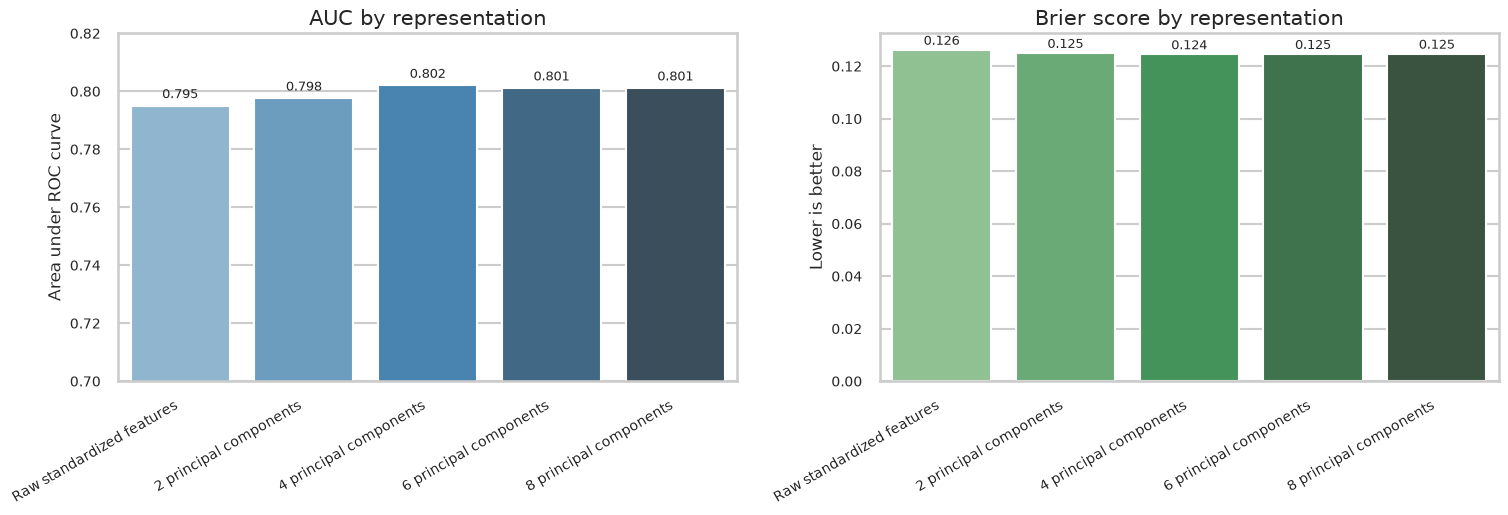

In [11]:
# Section focus: 6. Downstream Representation Test: Can a Smaller PCA Representation Preserve Predictive Signal?.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.5))
plot_frame = model_comparison.copy()

sns.barplot(data=plot_frame, x='representation', y='auc', palette='Blues_d', ax=axes[0])
axes[0].set_title('AUC by representation')
axes[0].set_xlabel('')
axes[0].set_ylabel('Area under ROC curve')
axes[0].set_ylim(0.70, max(0.82, plot_frame['auc'].max() + 0.01))
for tick in axes[0].get_xticklabels():
    tick.set_rotation(30)
    tick.set_horizontalalignment('right')
for patch, value in zip(axes[0].patches, plot_frame['auc']):
    axes[0].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.0015,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
    )

sns.barplot(data=plot_frame, x='representation', y='brier_score', palette='Greens_d', ax=axes[1])
axes[1].set_title('Brier score by representation')
axes[1].set_xlabel('')
axes[1].set_ylabel('Lower is better')
for tick in axes[1].get_xticklabels():
    tick.set_rotation(30)
    tick.set_horizontalalignment('right')
for patch, value in zip(axes[1].patches, plot_frame['brier_score']):
    axes[1].text(
        patch.get_x() + patch.get_width() / 2,
        patch.get_height() + 0.0008,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=9,
    )

plt.tight_layout()
plt.show()


The comparison is the important part, not whether one row wins by a tiny numerical margin.

In this simulation, a compact PCA representation preserves nearly all of the predictive signal and can even slightly outperform the raw linear baseline. That is plausible because PCA can reduce redundancy and stabilize the representation seen by a linear classifier.

The broader lesson is stronger than the exact metric values:

1. **Low-dimensional structure can be operationally useful and visually convenient.**
2. **The best number of components depends on the task.**
3. **Variance explained and predictive quality are related but not identical criteria.**

A representation that keeps 90 percent of variance may or may not keep the right decision signal. That is why downstream validation matters.


## 7. Practical Guidance for Decision Scientists

| Use case | Better default | Why |
|---|---|---|
| Quick compression of correlated numeric variables | PCA | Simple, explicit, reusable transformation |
| Analyst-facing loadings and interpretable latent summaries | PCA | Components can be tied back to original variables |
| Visualizing possible nonlinear structure in high-dimensional data | t-SNE or related embedding methods | Better neighborhood-preserving 2D views |
| Deployable representation for new incoming cases | PCA or another explicit feature map | Easy out-of-sample transformation |
| Communicating substantive meaning from a 2D plot | PCA with loadings, or careful narrative | t-SNE axes are not directly interpretable |

### Common mistakes to avoid

1. **Mistaking a visualization method for a deployable feature representation.**
2. **Reading too much into two-dimensional separation.** Some structure may only appear in higher components.
3. **Ignoring scale before PCA.** Standardization is usually essential for mixed operational variables.
4. **Treating explained variance as the only criterion.** Decision relevance and downstream performance matter too.
5. **Over-interpreting component signs.** The sign of a principal component can flip without changing the underlying geometry.


## Wrap-Up

This notebook treated dimensionality reduction as a decision-science tool rather than a generic plotting trick.

- On nonlinear geometry like the swiss roll, nonlinear embeddings can preserve local structure better than a simple linear projection.
- On correlated operational tabular data, PCA can recover compact and interpretable business dimensions.
- Compression quality should be judged with both structural diagnostics and downstream-task performance.

The practical takeaway is that dimensionality reduction is most useful when we are explicit about the goal. Sometimes we want a faithful visualization. Sometimes we want a compact operational feature set. Sometimes we want both, but the same method will not always serve both purposes equally well.

## References

- Abdi, H., & Williams, L. J. (2010). *Principal component analysis*. *Wiley Interdisciplinary Reviews: Computational Statistics, 2*(4), 433-459. [https://doi.org/10.1002/wics.101](https://doi.org/10.1002/wics.101)
- Jolliffe, I. T., & Cadima, J. (2016). *Principal component analysis: a review and recent developments*. *Philosophical Transactions of the Royal Society A, 374*(2065), 20150202. [https://doi.org/10.1098/rsta.2015.0202](https://doi.org/10.1098/rsta.2015.0202)
- Kang, B., García García, D., Lijffijt, J., Santos-Rodríguez, R., & De Bie, T. (2021). *Conditional t-SNE: more informative t-SNE embeddings*. *Machine Learning, 110*(10), 2905-2940. [https://doi.org/10.1007/s10994-020-05917-0](https://doi.org/10.1007/s10994-020-05917-0)
- Öztürk, Ü., & Yılmaz, A. (2021). *An optimization technique for linear manifold learning-based dimensionality reduction: evaluations on hyperspectral images*. *Applied Sciences, 11*(19), 9063. [https://doi.org/10.3390/app11199063](https://doi.org/10.3390/app11199063)
